In [276]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

#hacemos la funcion para "modularizar" los datos

def obt_datos():
    data = []
    for page in range(1, 6):
        url = f"http://quotes.toscrape.com/page/{page}/"
        response = requests.get(url)

        soup = BeautifulSoup(response.text, "html.parser")

        quotes = soup.find_all("span", class_="text")
        authors = soup.find_all("small", class_="author")

        for i in range(len(quotes)):
            data.append({
                "quote": quotes[i].text,
                "author": authors[i].text
            })

    return data

In [277]:
def analizar(df):
  autor_list = df['author'].value_counts()
  print(autor_list)

  print("Valores nulos por columna: ")
  print(df.isnull().sum())

#Buscamos generar y responder, cual es el autor que se repite más?
#Entonces primero hacemos nuestra variable tq

  autor_top = autor_list.index[0]
  print("Entonces el autor que mas se repite, es:", autor_top)
  return autor_list

In [278]:
def graficar(df, autor_list):

  autor_list= df['author'].value_counts().head(10)

  plt.pie(autor_list, labels=autor_list.index, autopct='%1.1f%%')
  plt.title("Distribución de autores")
  plt.show()

  #Hacemos una variable que guarde solo 5 autores, tq
  top_autores = df['author'].value_counts().head(5)

  #graficamos
  plt.bar(top_autores.index, top_autores.values)
  plt.xticks(rotation=45)
  plt.title("Top 5 autores más frecuentes")
  plt.show()

author
Albert Einstein           8
J.K. Rowling              6
Marilyn Monroe            6
Dr. Seuss                 3
Bob Marley                3
Mother Teresa             2
André Gide                1
Jane Austen               1
Steve Martin              1
Eleanor Roosevelt         1
Douglas Adams             1
Thomas A. Edison          1
Elie Wiesel               1
Friedrich Nietzsche       1
Allen Saunders            1
Mark Twain                1
Pablo Neruda              1
Ralph Waldo Emerson       1
Garrison Keillor          1
Jim Henson                1
Charles M. Schulz         1
William Nicholson         1
Jorge Luis Borges         1
George Eliot              1
George R.R. Martin        1
C.S. Lewis                1
Martin Luther King Jr.    1
James Baldwin             1
Name: count, dtype: int64
Valores nulos por columna: 
quote     0
author    0
dtype: int64
Entonces el autor que mas se repite, es: Albert Einstein


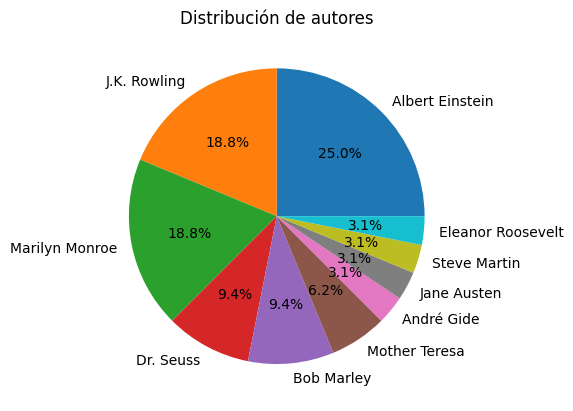

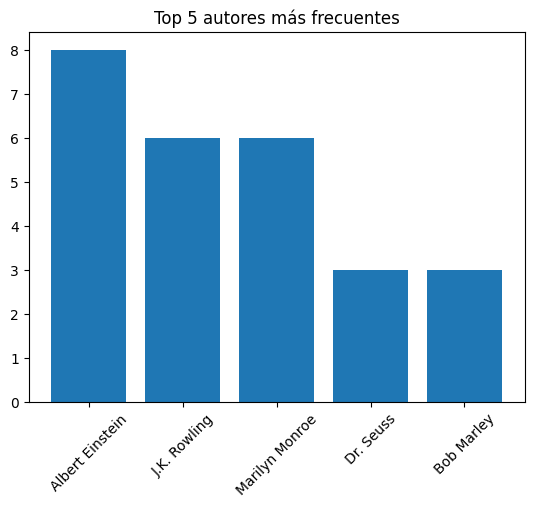

In [279]:
def main():
  data = obt_datos()
  df = pd.DataFrame(data)

  autor_list = analizar(df)
  graficar(df, autor_list)

if __name__ == "__main__":
  main()